# Corrección Metodológica en el Ensamble Heterogéneo: Optimización y Evaluación Independiente

Este notebook aborda un error metodológico crítico: la optimización y evaluación del ensamble heterogéneo utilizando el mismo conjunto de datos (fuga de datos o data leakage).

**Metodología corregida:**
1. **Separación de datos**: Dividimos el conjunto de prueba original de **DFUTissue** (16 imágenes) de manera determinista en dos subconjuntos independientes de 8 imágenes cada uno:
   - `validation_for_weights` (conjunto de optimización)
   - `validation_for_evaluation` (conjunto reservado de evaluación)
2. **Optimización de Pesos ($w_1$, $w_2$)**: Realizamos una búsqueda en cuadrícula (grid search) para encontrar los pesos óptimos $w_1$ y $w_2$ ($w_2 = 1 - w_1$) que maximizan el coeficiente Dice promedio sobre las clases activas de tejido ulceroso (Clases 1, 2 y 3) utilizando **únicamente** el conjunto `validation_for_weights`.
3. **Evaluación Final**: Evaluamos los modelos individuales (**ResUNet** y **U-Net++**) y el **Ensamble** final con los pesos optimizados en el conjunto reservado e independiente `validation_for_evaluation`.
4. **Resultados**: Exportamos los pesos y métricas óptimos en archivos CSV y creamos un gráfico comparativo del desempeño del mejor modelo individual frente al ensamble en el conjunto reservado.


In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# Definimos REPO_ROOT
REPO_ROOT = os.path.abspath("../..")
print(f"Raíz del repositorio: {REPO_ROOT}")

# Agregamos la ruta del paquete del ensamble para importar los modelos y dataset
sys.path.append(os.path.join(REPO_ROOT, "src/ClasificationAlgorithms/Models/Test_ensamble"))
from main_models import ResUnet, UnetPlusPlus
from dataset import DFUTissueDataset

print("Librerías y módulos importados correctamente.")


/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/diego-villalba/Proyecto_DFU/.venv/lib/python3.12/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Raíz del repositorio: /home/diego-villalba/Proyecto_DFU


torch.Size([3, 1, 160, 160])
Librerías y módulos importados correctamente.


## 1. División Determinista del Conjunto de Datos (Sin Fuga de Datos)
Dividimos de forma determinista (usando semilla fija `42`) las 16 imágenes de prueba en los dos conjuntos independientes.

In [2]:
# Definir directorios de imágenes y máscaras
test_image_dir = os.path.join(REPO_ROOT, "data", "dfu_tissue", "test_images")
test_mask_dir = os.path.join(REPO_ROOT, "data", "dfu_tissue", "test_masks")

# Obtener y ordenar todas las imágenes
all_images = sorted([f for f in os.listdir(test_image_dir) if f.endswith(".png")])
print(f"Total de imágenes encontradas: {len(all_images)}")

# Mezclar y dividir deterministamente usando semilla fija
random.seed(42)
shuffled_images = list(all_images)
random.shuffle(shuffled_images)

# 50% para optimización de pesos y 50% para evaluación final
opt_images = sorted(shuffled_images[:8])
eval_images = sorted(shuffled_images[8:])

print("\n--- Subconjunto de Optimización (validation_for_weights) ---")
print(opt_images)
print(f"Cantidad: {len(opt_images)}")

print("\n--- Subconjunto Reservado de Evaluación (validation_for_evaluation) ---")
print(eval_images)
print(f"Cantidad: {len(eval_images)}")


Total de imágenes encontradas: 16

--- Subconjunto de Optimización (validation_for_weights) ---
['0962.png', '0963.png', '0967.png', '0976.png', '0983.png', '0989.png', '0996.png', '1004.png']
Cantidad: 8

--- Subconjunto Reservado de Evaluación (validation_for_evaluation) ---
['0914.png', '0925.png', '0927.png', '0935.png', '0961.png', '0994.png', '0999.png', '1005.png']
Cantidad: 8


## 2. Definición del Dataset y Dataloader para Subconjuntos
Subclasificamos `DFUTissueDataset` para permitir la especificación de un subconjunto particular de nombres de archivo.

In [3]:
class SubsetDFUTissueDataset(DFUTissueDataset):
    def __init__(self, image_dir, mask_dir, image_files, transform=None):
        super().__init__(image_dir, mask_dir, transform)
        self.images = sorted(image_files)

# Transformaciones estándar para validación/prueba (Redimensionamiento y Normalización)
val_transforms = A.Compose([
    A.Resize(height=240, width=240),
    A.Normalize(
        mean=[0.0, 0.0, 0.0],
        std=[1.0, 1.0, 1.0],
        max_pixel_value=255.0,
    ),
    ToTensorV2(),
])

# Crear los Datasets
opt_dataset = SubsetDFUTissueDataset(test_image_dir, test_mask_dir, opt_images, transform=val_transforms)
eval_dataset = SubsetDFUTissueDataset(test_image_dir, test_mask_dir, eval_images, transform=val_transforms)

# Crear los Dataloaders
opt_loader = DataLoader(opt_dataset, batch_size=4, num_workers=0, pin_memory=True, shuffle=False)
eval_loader = DataLoader(eval_dataset, batch_size=4, num_workers=0, pin_memory=True, shuffle=False)

print(f"Dataloaders listos. Lotes de optimización: {len(opt_loader)}. Lotes de evaluación: {len(eval_loader)}")


Dataloaders listos. Lotes de optimización: 2. Lotes de evaluación: 2


## 3. Carga de los Modelos Entrenados

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo de ejecución: {DEVICE}")

# Rutas de los checkpoints de los modelos
resunet_checkpoint_path = os.path.join(REPO_ROOT, "notebooks/classification/output_assets_model/best_model_checkpoint_ResUnet.pth")
unetplusplus_checkpoint_path = os.path.join(REPO_ROOT, "notebooks/classification/output_assets_model/best_model_checkpoint_Unet++.pth")

# Cargar checkpoints
checkpoint_resunet = torch.load(resunet_checkpoint_path, map_location=DEVICE, weights_only=True)
checkpoint_unetplusplus = torch.load(unetplusplus_checkpoint_path, map_location=DEVICE, weights_only=True)

# Inicializar arquitecturas (4 canales de salida para segmentación de 4 clases)
model_resunet = ResUnet(in_channels=3, out_channels=4).to(DEVICE)
model_unetplusplus = UnetPlusPlus(in_channels=3, out_channels=4).to(DEVICE)

# Cargar estados
model_resunet.load_state_dict(checkpoint_resunet["state_dict"])
model_unetplusplus.load_state_dict(checkpoint_unetplusplus["state_dict"])

# Poner en modo de evaluación
model_resunet.eval()
model_unetplusplus.eval()

print("Modelos cargados y puestos en modo eval() correctamente.")


Dispositivo de ejecución: cuda


Modelos cargados y puestos en modo eval() correctamente.


## 4. Definición de la Función de Evaluación Cuantitativa
Esta función evalúa un modelo individual o un ensamble ponderado en un loader determinado y devuelve métricas completas por clase.

In [5]:
def evaluate_loader(loader, model1, model2=None, w1=1.0, num_classes=4, device="cuda"):
    """
    Evalúa model1 (si model2 es None) o un ensamble de model1 y model2
    donde logits_final = w1 * logits1 + (1 - w1) * logits2.
    """
    metrics = {
        "dice_coefficient": torch.zeros(num_classes, device=device),
        "IoU": torch.zeros(num_classes, device=device),
        "accuracy": torch.zeros(num_classes, device=device),
        "precision": torch.zeros(num_classes, device=device),
        "recall": torch.zeros(num_classes, device=device),
        "f1_score": torch.zeros(num_classes, device=device),
    }
    class_counts = torch.zeros(num_classes, device=device)
    
    if model1 is not None:
        model1.eval()
    if model2 is not None:
        model2.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            
            if model2 is None:
                logits = model1(x)
            else:
                logits1 = model1(x)
                logits2 = model2(x)
                logits = w1 * logits1 + (1.0 - w1) * logits2
            
            preds = torch.softmax(logits, dim=1)
            preds = torch.argmax(preds, dim=1)

            for cls in range(num_classes):
                true_positive = ((preds == cls) & (y == cls)).sum().float()
                false_positive = ((preds == cls) & (y != cls)).sum().float()
                false_negative = ((preds != cls) & (y == cls)).sum().float()
                true_negative = ((preds != cls) & (y != cls)).sum().float()

                metrics["dice_coefficient"][cls] += (2 * true_positive) / (2 * true_positive + false_positive + false_negative + 1e-8)
                metrics["IoU"][cls] += true_positive / (true_positive + false_positive + false_negative + 1e-8)
                metrics["accuracy"][cls] += (true_positive + true_negative) / (true_positive + true_negative + false_positive + false_negative + 1e-8)
                
                prec = true_positive / (true_positive + false_positive + 1e-8)
                rec = true_positive / (true_positive + false_negative + 1e-8)
                metrics["precision"][cls] += prec
                metrics["recall"][cls] += rec
                metrics["f1_score"][cls] += 2 * (prec * rec) / (prec + rec + 1e-8)
                
                class_counts[cls] += 1

    # Promediar sobre todos los lotes
    for key in metrics:
        metrics[key] /= class_counts

    dict_metrics = {key: metrics[key].cpu().numpy() for key in metrics}
    return dict_metrics


## 5. Optimización de Pesos ($w_1$, $w_2$) en `validation_for_weights`
Realizamos una búsqueda en cuadrícula para encontrar el peso $w_1$ que maximiza el Dice promedio de las clases de tejido ulceroso (Clases 1, 2 y 3).

Iniciando búsqueda en cuadrícula de pesos en el conjunto de optimización...



[OPTIMIZACIÓN COMPLETADA]
Mejor w1 (ResUNet): 0.00
Mejor w2 (U-Net++): 1.00
Dice promedio de tejidos activos de la herida en optimización: 0.5411
Dice promedio de todas las clases en optimización: 0.6335
Pesos del ensamble exportados correctamente a /home/diego-villalba/Proyecto_DFU/results/ensemble_analysis/ensemble_weights.csv


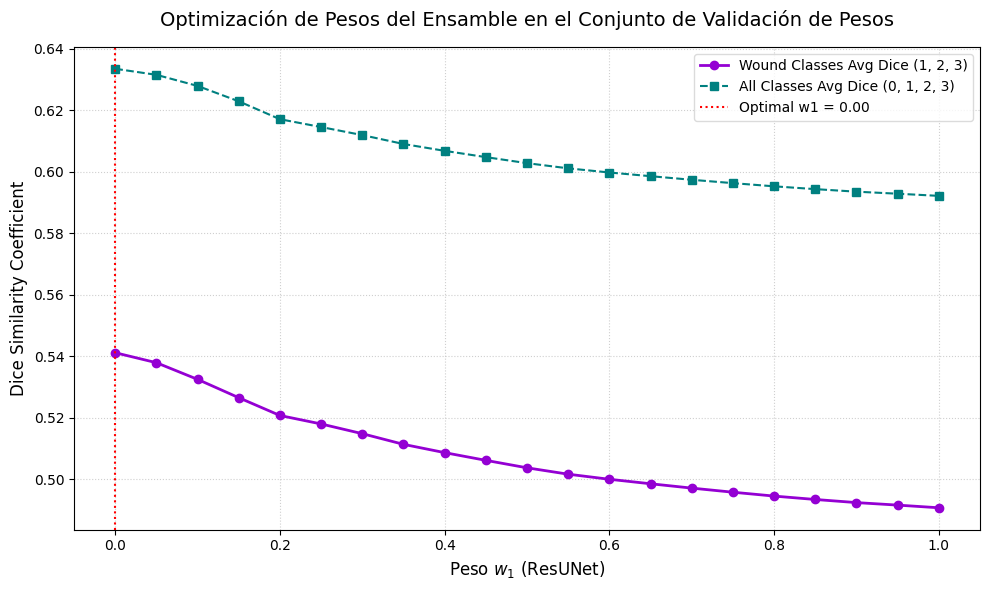

In [6]:
w1_values = np.linspace(0.0, 1.0, 21) # Paso de 0.05
opt_results = []

print("Iniciando búsqueda en cuadrícula de pesos en el conjunto de optimización...")

for w1 in w1_values:
    res = evaluate_loader(opt_loader, model_resunet, model_unetplusplus, w1=w1, device=DEVICE)
    # Calculamos el promedio del coeficiente Dice sobre las clases activas de tejido ulceroso (1, 2, 3)
    dice_classes = res["dice_coefficient"]
    wound_dice_avg = np.mean(dice_classes[1:4]) # Clases 1, 2, 3
    mean_dice_all = np.mean(dice_classes) # Clases 0, 1, 2, 3
    
    opt_results.append({
        "w1": w1,
        "w2": 1.0 - w1,
        "dice_class_0": dice_classes[0],
        "dice_class_1": dice_classes[1],
        "dice_class_2": dice_classes[2],
        "dice_class_3": dice_classes[3],
        "wound_dice_avg": wound_dice_avg,
        "mean_dice_all": mean_dice_all
    })

df_opt = pd.DataFrame(opt_results)

# Encontrar el peso w1 que maximiza el Dice promedio de los tejidos de la herida
best_idx = df_opt["wound_dice_avg"].idxmax()
best_row = df_opt.loc[best_idx]
best_w1 = best_row["w1"]
best_w2 = best_row["w2"]

print(f"\n[OPTIMIZACIÓN COMPLETADA]")
print(f"Mejor w1 (ResUNet): {best_w1:.2f}")
print(f"Mejor w2 (U-Net++): {best_w2:.2f}")
print(f"Dice promedio de tejidos activos de la herida en optimización: {best_row['wound_dice_avg']:.4f}")
print(f"Dice promedio de todas las clases en optimización: {best_row['mean_dice_all']:.4f}")

# Guardar los pesos optimizados en results/ensemble_analysis/ensemble_weights.csv
weights_dir = os.path.join(REPO_ROOT, "results", "ensemble_analysis")
os.makedirs(weights_dir, exist_ok=True)
weights_path = os.path.join(weights_dir, "ensemble_weights.csv")

weights_df = pd.DataFrame({
    "weight_name": ["w1", "w2"],
    "model_name": ["ResUNet", "U-Net++"],
    "value": [best_w1, best_w2]
})
weights_df.to_csv(weights_path, index=False)
print(f"Pesos del ensamble exportados correctamente a {weights_path}")

# Graficar la curva de optimización de pesos
plt.figure(figsize=(10, 6))
plt.plot(df_opt["w1"], df_opt["wound_dice_avg"], marker='o', color='darkviolet', linewidth=2, label="Wound Classes Avg Dice (1, 2, 3)")
plt.plot(df_opt["w1"], df_opt["mean_dice_all"], marker='s', color='teal', linestyle='--', label="All Classes Avg Dice (0, 1, 2, 3)")
plt.axvline(x=best_w1, color='red', linestyle=':', label=f"Optimal w1 = {best_w1:.2f}")
plt.title("Optimización de Pesos del Ensamble en el Conjunto de Validación de Pesos", fontsize=14, pad=15)
plt.xlabel("Peso $w_1$ (ResUNet)", fontsize=12)
plt.ylabel("Dice Similarity Coefficient", fontsize=12)
plt.legend(frameon=True, facecolor='white', edgecolor='lightgray')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(weights_dir, "ensemble_weight_optimization_curve.png"), dpi=300)
plt.show()


## 6. Evaluación en el Conjunto Reservado (`validation_for_evaluation`)
Ahora evaluamos individualmente a **ResUNet**, **U-Net++**, y a su **Ensamble** final optimizado en el conjunto reservado de prueba para obtener métricas limpias y libres de fuga de datos.

In [7]:
# 1. Evaluar ResUNet individual (equivale a w1 = 1.0)
metrics_resunet = evaluate_loader(eval_loader, model_resunet, model2=None, device=DEVICE)

# 2. Evaluar U-Net++ individual (equivale a w1 = 0.0)
metrics_unetplusplus = evaluate_loader(eval_loader, model_unetplusplus, model2=None, device=DEVICE)

# 3. Evaluar Ensamble con pesos optimizados (w1 = best_w1)
metrics_ensemble = evaluate_loader(eval_loader, model_resunet, model_unetplusplus, w1=best_w1, device=DEVICE)

print("Evaluación en subconjunto reservado finalizada.")


Evaluación en subconjunto reservado finalizada.


## 7. Consolidación y Exportación de Métricas

In [8]:
# Crear registros de métricas detallados por modelo y clase
records = []
model_names = ["ResUNet", "U-Net++", "Ensemble"]
model_metrics = [metrics_resunet, metrics_unetplusplus, metrics_ensemble]

class_labels = {0: "Background", 1: "Granulation", 2: "Slough", 3: "Necrotic"}

for model_name, m_dict in zip(model_names, model_metrics):
    for cls in range(4):
        records.append({
            "model": model_name,
            "class_id": cls,
            "class_name": class_labels[cls],
            "dice": m_dict["dice_coefficient"][cls],
            "iou": m_dict["IoU"][cls],
            "accuracy": m_dict["accuracy"][cls],
            "precision": m_dict["precision"][cls],
            "recall": m_dict["recall"][cls],
            "f1_score": m_dict["f1_score"][cls]
        })
    
    # Agregar fila de promedio macro de clases de la herida (1, 2, 3)
    records.append({
        "model": model_name,
        "class_id": -1,
        "class_name": "Wound Average (1-3)",
        "dice": np.mean(m_dict["dice_coefficient"][1:4]),
        "iou": np.mean(m_dict["IoU"][1:4]),
        "accuracy": np.mean(m_dict["accuracy"][1:4]),
        "precision": np.mean(m_dict["precision"][1:4]),
        "recall": np.mean(m_dict["recall"][1:4]),
        "f1_score": np.mean(m_dict["f1_score"][1:4])
    })
    
    # Agregar fila de promedio general (todas las clases)
    records.append({
        "model": model_name,
        "class_id": -2,
        "class_name": "All Classes Average",
        "dice": np.mean(m_dict["dice_coefficient"]),
        "iou": np.mean(m_dict["IoU"]),
        "accuracy": np.mean(m_dict["accuracy"]),
        "precision": np.mean(m_dict["precision"]),
        "recall": np.mean(m_dict["recall"]),
        "f1_score": np.mean(m_dict["f1_score"])
    })

df_metrics = pd.DataFrame(records)

# Exportar métricas a results/ensemble_analysis/ensemble_metrics.csv
metrics_path = os.path.join(weights_dir, "ensemble_metrics.csv")
df_metrics.to_csv(metrics_path, index=False)
print(f"Métricas del ensamble exportadas a {metrics_path}")

# Mostrar las métricas consolidadas en formato legible
print("\n--- Resumen del Desempeño en el Conjunto Reservado ---")
df_summary = df_metrics[df_metrics["class_name"].isin(["Wound Average (1-3)", "All Classes Average"])].sort_values(by=["class_name", "dice"], ascending=[True, False])
print(df_summary[["model", "class_name", "dice", "iou", "f1_score"]])


Métricas del ensamble exportadas a /home/diego-villalba/Proyecto_DFU/results/ensemble_analysis/ensemble_metrics.csv

--- Resumen del Desempeño en el Conjunto Reservado ---
       model           class_name      dice       iou  f1_score
11   U-Net++  All Classes Average  0.698821  0.590933  0.698821
17  Ensemble  All Classes Average  0.698821  0.590933  0.698821
5    ResUNet  All Classes Average  0.672467  0.570741  0.672467
10   U-Net++  Wound Average (1-3)  0.629943  0.511832  0.629943
16  Ensemble  Wound Average (1-3)  0.629943  0.511832  0.629943
4    ResUNet  Wound Average (1-3)  0.592612  0.481558  0.592612


## 8. Identificación del Mejor Modelo Individual y Comparación con el Ensamble
Determinamos cuál modelo de los dos individuales obtuvo el mayor Dice promedio en las clases activas de la herida en el conjunto reservado y creamos la figura comparativa.

Mejor modelo individual: U-Net++ (Wound Dice: 0.6299)


Figura comparativa guardada exitosamente en /home/diego-villalba/Proyecto_DFU/results/figures/ensemble_vs_best_model.png


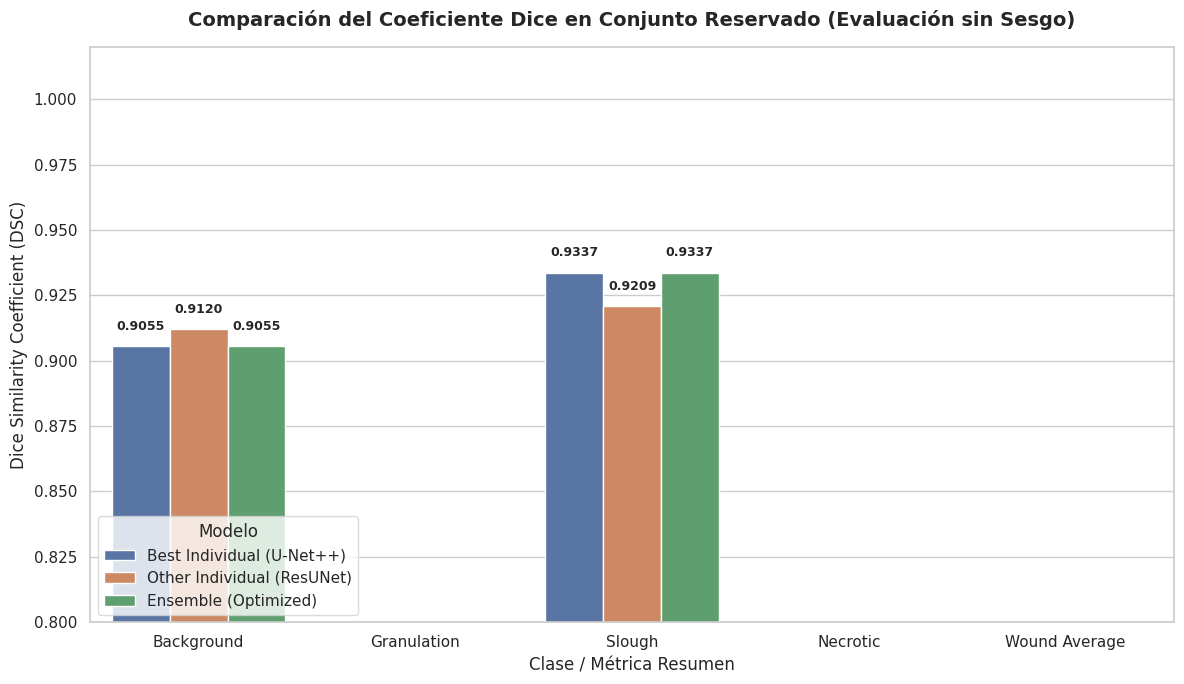

In [9]:
# Obtener el promedio de clases ulcerosas para cada modelo individual
resunet_wound_dice = np.mean(metrics_resunet["dice_coefficient"][1:4])
unetplusplus_wound_dice = np.mean(metrics_unetplusplus["dice_coefficient"][1:4])

if resunet_wound_dice >= unetplusplus_wound_dice:
    best_ind_name = "ResUNet"
    best_ind_metrics = metrics_resunet
else:
    best_ind_name = "U-Net++"
    best_ind_metrics = metrics_unetplusplus

print(f"Mejor modelo individual: {best_ind_name} (Wound Dice: {max(resunet_wound_dice, unetplusplus_wound_dice):.4f})")

# Preparar datos para graficar la comparación
# Compararemos el Coeficiente Dice por clase y promedio para el mejor modelo individual, el otro modelo y el ensamble
classes_plot = ["Background", "Granulation", "Slough", "Necrotic", "Wound Average"]
best_ind_vals = list(best_ind_metrics["dice_coefficient"]) + [np.mean(best_ind_metrics["dice_coefficient"][1:4])]
other_ind_name = "U-Net++" if best_ind_name == "ResUNet" else "ResUNet"
other_ind_metrics = metrics_unetplusplus if best_ind_name == "ResUNet" else metrics_resunet
other_ind_vals = list(other_ind_metrics["dice_coefficient"]) + [np.mean(other_ind_metrics["dice_coefficient"][1:4])]
ensemble_vals = list(metrics_ensemble["dice_coefficient"]) + [np.mean(metrics_ensemble["dice_coefficient"][1:4])]

# Crear DataFrame para graficar con Seaborn
plot_data = []
for cls_name, bi_val, oi_val, ens_val in zip(classes_plot, best_ind_vals, other_ind_vals, ensemble_vals):
    plot_data.append({"Class": cls_name, "Model": f"Best Individual ({best_ind_name})", "Dice Score": bi_val})
    plot_data.append({"Class": cls_name, "Model": f"Other Individual ({other_ind_name})", "Dice Score": oi_val})
    plot_data.append({"Class": cls_name, "Model": "Ensemble (Optimized)", "Dice Score": ens_val})

df_plot = pd.DataFrame(plot_data)

# Configurar estilo visual premium
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# Graficar barras agrupadas
ax = sns.barplot(
    data=df_plot,
    x="Class",
    y="Dice Score",
    hue="Model",
    palette=["#4c72b0", "#dd8452", "#55a868"] # Colores limpios y premium
)

plt.title("Comparación del Coeficiente Dice en Conjunto Reservado (Evaluación sin Sesgo)", fontsize=14, pad=15, fontweight='bold')
plt.xlabel("Clase / Métrica Resumen", fontsize=12)
plt.ylabel("Dice Similarity Coefficient (DSC)", fontsize=12)
plt.ylim(0.8, 1.02) # Ajustar escala para apreciar diferencias sutiles
plt.legend(title="Modelo", frameon=True, loc="lower left", facecolor='white', edgecolor='lightgray')

# Añadir valores sobre las barras
for p in ax.patches:
    height = p.get_height()
    if height > 0.0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height + 0.005),
                    ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)

plt.tight_layout()

# Guardar la figura comparativa en results/figures/ensemble_vs_best_model.png
figures_dir = os.path.join(REPO_ROOT, "results/figures")
os.makedirs(figures_dir, exist_ok=True)
figure_path = os.path.join(figures_dir, "ensemble_vs_best_model.png")
plt.savefig(figure_path, dpi=300)
print(f"Figura comparativa guardada exitosamente en {figure_path}")
plt.show()
